<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo-1.jpg" align="left" width=300></p></td><td><font size=3><B>Data analysis (Python)-  homework for week 10</B></font></td></tr></table>

tips 
- rename the name jupyter notebook file following the rules: **replace ID and name with your student ID and your own name**

In [43]:
name = input("what is your name: ")

what is your name: 1


In [44]:
student_ID = input("what is your student ID: ")

what is your student ID: 1


# Part One (25 points)

please measure intraday volatility by dividing the daily difference between the highest and lowest share prices by the average of the opening and closing prices. get the day with highest  on which volatility.

$$ volatility = \frac{High - Low}{(Open+Close)/2}$$
tips - 
* data - 000001_trade.csv
* print the date with largest volatility

In [45]:
import pandas as pd
data_path = "000001_trade.csv"
# please start code here
trade_sh = pd.read_csv("000001_trade.csv",index_col = "Date",parse_dates = ["Date"]) # laod data
trade_sh["volatility"]=(trade_sh["High"]-trade_sh["Low"])/((trade_sh["Open"]+trade_sh["Close"])/2)
m = trade_sh["volatility"].max() # 找到最大值
s = (trade_sh["volatility"] == m) # 布尔切片
print(trade_sh[s])



                   High          Low         Open        Close  Volume  \
Date                                                                     
2015-07-09  3748.479004  3373.540039  3432.454102  3709.330078  656900   

              Adj Close  volatility  
Date                                 
2015-07-09  3709.330078    0.104999  


In [46]:

trade_sh.idxmax(axis=0) # 使用dixmax命令，注意有方向性，确定每一列的最大值

High         2015-06-12
Low          2015-06-12
Open         2015-06-15
Close        2015-06-12
Volume       2015-04-20
Adj Close    2015-06-12
volatility   2015-07-09
dtype: datetime64[ns]

# Part Two (25 points)
I load the data titanic.csv and assign it to variable titanic. please complete the following three tasks 
* [drop](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html) column of Name
* generate [dummy variables](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) for Sex column
* compute pairwise [correlation of columns] (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)

In [47]:
titanic = pd.read_csv("titanic.csv")
titanic.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [48]:
# task 1 - remove column Name 
# start code here

titanic.drop("Name",axis=1,inplace=True) # 删除某一列，注意 inplace=True
titanic.head()


,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


In [49]:
# task 2 - generate dummy variables for Sex column
# start code here
Sex = titanic.Sex.str.get_dummies() # 哑变量处理
new_titanic = pd.concat([titanic,Sex],axis=1) # 两个表格链接，按照行方向链接
new_titanic



,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,female,male
0,0,3,male,22.0,1,0,7.2500,0,1
1,1,1,female,38.0,1,0,71.2833,1,0
2,1,3,female,26.0,0,0,7.9250,1,0
3,1,1,female,35.0,1,0,53.1000,1,0
4,0,3,male,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...,...
882,0,2,male,27.0,0,0,13.0000,0,1
883,1,1,female,19.0,0,0,30.0000,1,0
884,0,3,female,7.0,1,2,23.4500,1,0
885,1,1,male,26.0,0,0,30.0000,0,1


In [50]:
new_titanic.drop("Sex",axis=1,inplace=True) # 删除某一列（先去除字符串，苹果系统才能进行比较）
new_titanic.head()

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,female,male
0,0,3,22.0,1,0,7.2500,0,1
1,1,1,38.0,1,0,71.2833,1,0
2,1,3,26.0,0,0,7.9250,1,0
3,1,1,35.0,1,0,53.1000,1,0
4,0,3,35.0,0,0,8.0500,0,1


In [51]:
# task 3 - compute pairwise correlation of columns 相关性分析
# start code here
new_titanic.corr()



,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,female,male
Survived,1.000000,-0.336528,-0.059665,-0.037082,0.080097,0.256179,0.542152,-0.542152
Pclass,-0.336528,1.000000,-0.391492,0.085026,0.020252,-0.548919,-0.129507,0.129507
Age,-0.059665,-0.391492,1.000000,-0.297669,-0.193741,0.112329,-0.091875,0.091875
Siblings/Spouses Aboard,-0.037082,0.085026,-0.297669,1.000000,0.414244,0.158839,0.113249,-0.113249
Parents/Children Aboard,0.080097,0.020252,-0.193741,0.414244,1.000000,0.215470,0.244337,-0.244337
Fare,0.256179,-0.548919,0.112329,0.158839,0.215470,1.000000,0.181137,-0.181137
female,0.542152,-0.129507,-0.091875,0.113249,0.244337,0.181137,1.000000,-1.000000
male,-0.542152,0.129507,0.091875,-0.113249,-0.244337,-0.181137,-1.000000,1.000000


### df.corr() 例子

In [52]:
df = pd.DataFrame([(.2, .3), (.0, .6), (.6, .0), (.2, .1)],
                  columns=['dogs', 'cats'])
df

,dogs,cats
0,0.2,0.3
1,0.0,0.6
2,0.6,0.0
3,0.2,0.1


In [53]:
df.corr()

,dogs,cats
dogs,1.000000,-0.851064
cats,-0.851064,1.000000


# Part Three (25 points)
Please count the unique users who have posted comment longer than 900 words in the cleaned dataset.

tips
- data - cleaned_300251_comments-New.csv
- to count the unique users, please try [unique function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.unique.html)

In [3]:
import pandas as pd
# load the cleaned comments
comments = pd.read_csv("cleaned_300251_comments-New.csv",
                      index_col=["modified_date"],
                      parse_dates = ["modified_date"],
                      usecols= ["modified_date","comment","author","hour","dayofweek","month"])

# 找出字数大于900的所有作者

bool_slice = (comments.comment.str.len()>900) # 选取规则
author_long = comments[bool_slice].author # 布尔切片


print(author_long)
unique_authors = author_long.unique()

#作用：unique函数去除其中重复的元素，并按元素由大到小返回一个新的无元素重复的元组或者列表

print(len(unique_authors))
unique_authors

modified_date
2011-08-05              NaN
2011-08-28              NaN
2011-09-09              NaN
2011-10-27              NaN
2011-10-28              NaN
                  ...      
2019-02-12     市界Newsseeker
2019-02-12             散人看市
2019-02-12    水牛哥2624818115
2019-02-12     市界Newsseeker
2019-02-12             散人看市
Name: author, Length: 81, dtype: object
36


array([nan, '信息达人', '龙年浴火重生', '释疑', '小加菲bb', 'ggbbnhh', '财富狙击', '黄金快讯',
       '个股探秘', '联信永益永远长青', '公司研究', '股友GHoIEV', '张金博', '一本正经的胡扯', '洒家是也',
       'RogerFederer', '长河大格局4013', '股友cRKlzB', '阿龙短线天机', '一叶财经', '盒饭财经',
       '吴国平', '股海天涯深圳', 'a黄乔论股', 'capitalweek88', '评点经济', '股友rEOeAR',
       '彪哥说股', '卧龙轩wlx', '老王撩影视', '市界Newsseeker', '基结号', '常建武', '股票杂谈',
       '水牛哥2624818115', '散人看市'], dtype=object)

# Part Four  (25 points)
I load the data titanic.csv and assign it to variable titanic. **your task - please group the data according to Pclass and visulize the average survived rates for each class.**


I present a chart here as a demonstration

<img src="../img/survive.png" align='left' height="300" width="400"/>

/var/folders/kb/tv69ch3n1936k84ysf8skrph0000gn/T/ipykernel_73993/730239551.py:4: FutureWarning: The provided callable <function sum at 0x7fd408d9e280> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  titanic_pclass_survived = titanic.groupby("Pclass").Survived.aggregate(np.sum)


<Axes: xlabel='Pclass'>

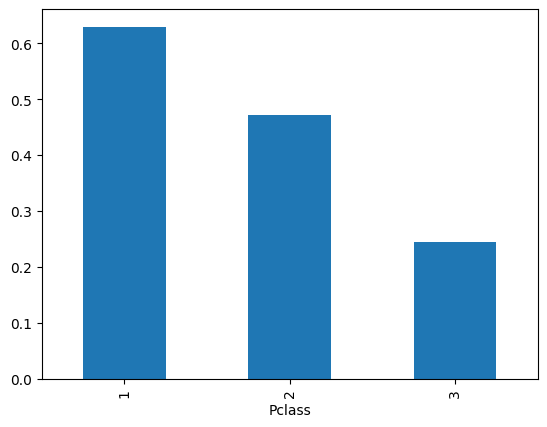

In [55]:
# 方法-1

titanic = pd.read_csv("titanic.csv")
# Please start programming here
import numpy as np
titanic_pclass_survived = titanic.groupby("Pclass").Survived.aggregate(np.sum) 

# 实现数据拆分并计算加总（根据参数方法）的方法

###存活的人数

titanic_pclass_total = titanic.Pclass.value_counts()

###总人数

ratio = titanic_pclass_survived/titanic_pclass_total # 计算公式

ratio.plot(kind="bar")

In [56]:
ratio

Pclass
1    0.629630
2    0.472826
3    0.244353
dtype: float64

In [57]:
# 方法-2

table = pd.pivot_table(data=titanic,values="Survived",index=["Pclass"],
                       aggfunc=np.mean)# 进行均值计算

## 数据透视表的方法 pd.pivot_table

table

/var/folders/kb/tv69ch3n1936k84ysf8skrph0000gn/T/ipykernel_73993/2912543429.py:1: FutureWarning: The provided callable <function mean at 0x7fd408da31f0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  table = pd.pivot_table(data=titanic,values="Survived",index=["Pclass"],


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.244353


/var/folders/kb/tv69ch3n1936k84ysf8skrph0000gn/T/ipykernel_73993/1213777451.py:1: FutureWarning: The provided callable <function mean at 0x7fd408da31f0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  table = pd.pivot_table(data=titanic,values="Survived",index=["Pclass"],


<Axes: xlabel='Pclass'>

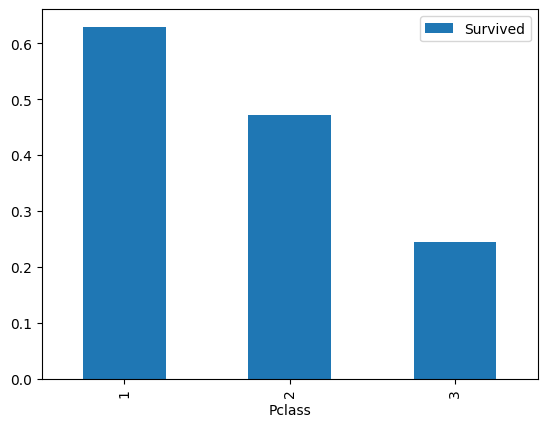

In [58]:
table = pd.pivot_table(data=titanic,values="Survived",index=["Pclass"],
                       aggfunc=np.mean)
table.plot(kind="bar")

/var/folders/kb/tv69ch3n1936k84ysf8skrph0000gn/T/ipykernel_73993/2116329389.py:1: FutureWarning: The provided callable <function mean at 0x7fd408da31f0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  table = pd.pivot_table(data=titanic,values="Survived",index=["Pclass"],columns=["Sex"],


<Axes: xlabel='Pclass'>

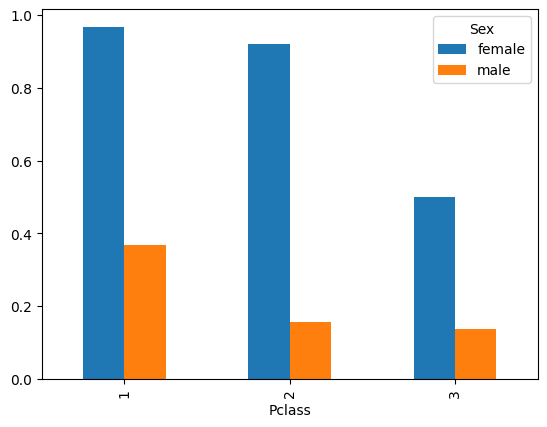

In [59]:
table = pd.pivot_table(data=titanic,values="Survived",index=["Pclass"],columns=["Sex"],
                       aggfunc=np.mean) # 也可以选择列标签
table.plot(kind="bar")


**I also include some learning materials here. I hope that you can study it by yourself.**
* [10 minutes to pandas](https://pandas.pydata.org/pandas-docs/stable/getting_started/10min.html)
* [Indexing and selecting data](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html)
* [Working with text data](https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html)